# Pipeline de Ingesta de Datos — Entrega 1

**Proyecto Integrador — Ciencia de Datos (UTN FRM)**

**Tema:** predecir el tipo de lesión de jugadores de la Premier League a partir de la congestión de partidos (minutos jugados en los últimos 7 días).

Este notebook arma el pipeline de ingeniería de datos:

1. Descarga automatizada de los datasets fuente desde Zenodo.
2. Categorización de las lesiones en clases médico-deportivas.
3. Filtrado en streaming del panel día-a-día (pesado) para quedarnos solo con los jugadores relevantes.
4. Join final de las tres fuentes en un dataset a nivel jugador-día.
5. Verificación de integridad del dataset resultante.

**Fuente de datos:** [Zenodo record 17835138](https://zenodo.org/records/17835138) — licencia CC-BY 4.0.

In [1]:
# Imports and base paths
import re
import time
from pathlib import Path

import pandas as pd
import requests
from tqdm.notebook import tqdm

RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"RAW_DIR: {RAW_DIR.resolve()}")
print(f"PROCESSED_DIR: {PROCESSED_DIR.resolve()}")

RAW_DIR: C:\Users\bauti\UTN\Quinto Año\CienciaDeDatos\data\raw
PROCESSED_DIR: C:\Users\bauti\UTN\Quinto Año\CienciaDeDatos\data\processed


## Sección 1 — Descarga automatizada

Descargamos los 3 archivos fuente desde el repositorio [Zenodo record 17835138](https://zenodo.org/records/17835138) (licencia CC-BY 4.0) hacia `data/raw/`, usando `requests` (no descarga manual) con manejo de errores y barra de progreso:

- **`tm_injuries_clean.csv`**: registros de lesiones por jugador, con descripción libre (`injury_desc`).
- **`player_mapping_tm.csv`**: tabla de traducción entre `tm_player_id` (Transfermarkt) y `fbref_player_id` (FBref).
- **`player_day_panel.csv`**: panel día a día por jugador con minutos jugados y congestión de partidos. **Pesa ~540 MB**, así que la descarga puede tardar varios minutos — mostramos una barra de progreso para seguir el avance.

Si un archivo ya existe en `data/raw/`, se omite la descarga (para no volver a bajar 540 MB en cada re-ejecución del notebook).

In [2]:
def download_file(url: str, dest_path: Path, chunk_size: int = 8192) -> bool:
    """Download a file with a progress bar, skipping if it already exists.

    Returns True if the file was downloaded, False if it was skipped.
    """
    if dest_path.exists():
        size_mb = dest_path.stat().st_size / (1024 ** 2)
        print(f"[skip] {dest_path.name} ya existe ({size_mb:.1f} MB)")
        return False

    tmp_path = dest_path.with_suffix(dest_path.suffix + ".part")
    try:
        with requests.get(url, stream=True, timeout=60) as response:
            response.raise_for_status()
            total_size = int(response.headers.get("Content-Length", 0))

            with open(tmp_path, "wb") as f, tqdm(
                total=total_size,
                unit="B",
                unit_scale=True,
                unit_divisor=1024,
                desc=dest_path.name,
            ) as bar:
                for chunk in response.iter_content(chunk_size=chunk_size):
                    if chunk:
                        f.write(chunk)
                        bar.update(len(chunk))

        tmp_path.rename(dest_path)
        print(f"[ok] {dest_path.name} descargado correctamente")
        return True

    except requests.exceptions.RequestException as exc:
        if tmp_path.exists():
            tmp_path.unlink()
        print(f"[error] Fallo al descargar {dest_path.name}: {exc}")
        raise

In [3]:
ZENODO_FILES = {
    "tm_injuries_clean.csv": "https://zenodo.org/records/17835138/files/tm_injuries_clean.csv?download=1",
    "player_mapping_tm.csv": "https://zenodo.org/records/17835138/files/player_mapping_tm.csv?download=1",
    "player_day_panel.csv": "https://zenodo.org/records/17835138/files/player_day_panel.csv?download=1",
}

for filename, url in ZENODO_FILES.items():
    dest = RAW_DIR / filename
    if filename == "player_day_panel.csv" and not dest.exists():
        print(f"Nota: {filename} pesa ~540 MB, la descarga puede tardar varios minutos...")
    download_file(url, dest)

[skip] tm_injuries_clean.csv ya existe (2.7 MB)
[skip] player_mapping_tm.csv ya existe (0.4 MB)
[skip] player_day_panel.csv ya existe (515.5 MB)


In [4]:
# Verify downloaded files
for filename in ZENODO_FILES:
    path = RAW_DIR / filename
    size_mb = path.stat().st_size / (1024 ** 2)
    print(f"{filename}: {size_mb:.2f} MB")

tm_injuries_clean.csv: 2.71 MB
player_mapping_tm.csv: 0.38 MB
player_day_panel.csv: 515.54 MB


## Sección 2 — Categorización de lesiones

`tm_injuries_clean.csv` tiene descripciones de lesión en texto libre (`injury_desc`, 289 valores distintos). Para poder usar el tipo de lesión como variable objetivo de clasificación multiclase, las agrupamos en 13 categorías médico-deportivas mediante un conjunto de reglas por expresiones regulares (definidas a partir de un script de categorización ya validado).

Aplicamos la función `categorize()` sobre cada `injury_desc` de `tm_injuries_clean.csv`, generamos la columna `injury_category`, guardamos el resultado en `data/raw/tm_injuries_categorized.csv`, y visualizamos la distribución resultante.

In [5]:
# Injury categorization rules (ordered: first matching pattern wins)
INJURY_CATEGORY_RULES = [
    ("Fractura/Oseo", r"fractur|broken|bone (edema|bruise|sprain|splintering)|hairline|crack in|fissure|stress reaction of the bone|dislocation|skull|cheekbone|collarbone|metacarpal|metatarsal(?! bruise)"),
    ("Ligamentos/Articular", r"ligament|cruciate|meniscus|cartilage|capsul|syndesmo|acromioclavicular|joint (dislocation|capsular)|collateral|bursitis|\bsprain\b|inflammation (in|of) the knee|edema in the knee"),
    ("Tendon", r"tendon|tendin|achilles"),
    ("Muscular", r"muscl|muscul|hamstring|calf|thigh|adductor|groin|strain|abdominal muscle|hip flexor|contracture|pubalgia|sciatica|dead leg|pubic bone"),
    ("Contusion/Golpe", r"knock|bruise|bruised|contusion|cut\b|laceration|wound|whiplash"),
    ("Enfermedad/Infeccion", r"\bill\b|flu|influenza|virus|corona|covid|fever|cold\b|infection|inflammation(?! (in|of) the knee)|tonsil|appendic|hernia|stomach|mononucle|malaria|pneumon|bronchitis|chickenpox|shingles|tuberculosis|meningitis|food poisoning|allerg|kidney (problems|stone)|heart problems|angina|cancer|depression|cyst|skin disease|quarantine"),
    ("Cirugia", r"surgery|arthroscopy|dental|remove screws|appendectomy|toothache"),
    ("Cabeza/Cara", r"head injury|concussion|eardrum|nose|facial|jaw|eye injury|eyebow|cheekbone bruise"),
    ("Espalda/Columna", r"back (injury|problems|bruise|blockage)|lumbago|lumbar|herniated disc|spine|vertebra|coccyx|cervical"),
    # "Otra_zona" split into anatomical sub-regions (2026-08-17): the original
    # bucket mixed body parts with no biomechanical relation to each other.
    ("Tobillo_Pie", r"ankle|foot|toe|heel|shin"),
    ("Rodilla", r"knee"),
    ("Hombro_Brazo_Mano", r"shoulder|arm|elbow|wrist|hand|finger|thumb"),
    ("Cadera_Cintura", r"hip|pelvi"),
    ("Cuello_Torax", r"neck injury|chest|rib"),
    ("Pierna_general", r"\bleg injury\b"),
    ("Otra_zona_residual", r"arch problems|contortion|abdominal problems"),
    ("Fatiga/Descanso/Sin_especificar", r"unknown|rest\b|fitness\b|fatigue(?! fracture)|overstretch|stiffness"),
    ("Otro/Accidente", r"traffic accident|pneumothorax|insect bite|testicular|lymphatic|circulation|pinched nerve|vein occlusion|lung|cerebral|kidney stone surgery"),
]


def categorize(desc: str) -> str:
    """Map a free-text injury description to a medical-sports category.

    Returns "Sin_clasificar" if no rule matches (flagged for manual review).
    """
    d = desc.lower()
    for category, pattern in INJURY_CATEGORY_RULES:
        if re.search(pattern, d):
            return category
    return "Sin_clasificar"

In [6]:
# Apply categorization to the injuries dataset
injuries_df = pd.read_csv(RAW_DIR / "tm_injuries_clean.csv")
injuries_df["injury_category"] = injuries_df["injury_desc"].apply(categorize)

injuries_df.to_csv(RAW_DIR / "tm_injuries_categorized.csv", index=False)

n_unclassified = (injuries_df["injury_category"] == "Sin_clasificar").sum()
print(f"Filas categorizadas: {len(injuries_df)}")
print(f"Sin clasificar (revisar manualmente): {n_unclassified}")

Filas categorizadas: 16838
Sin clasificar (revisar manualmente): 2


In [7]:
# Distribution table
category_counts = injuries_df["injury_category"].value_counts()
category_table = category_counts.rename_axis("injury_category").reset_index(name="count")
category_table["pct"] = (category_table["count"] / category_table["count"].sum() * 100).round(1)
category_table

,injury_category,count,pct
0,Muscular,6359,37.8
1,Enfermedad/Infeccion,1535,9.1
2,Fatiga/Descanso/Sin_especificar,1504,8.9
3,Tobillo_Pie,1436,8.5
4,Rodilla,1355,8.0
5,Contusion/Golpe,1322,7.9
6,Ligamentos/Articular,960,5.7
7,Fractura/Oseo,442,2.6
8,Espalda/Columna,365,2.2
9,Hombro_Brazo_Mano,332,2.0


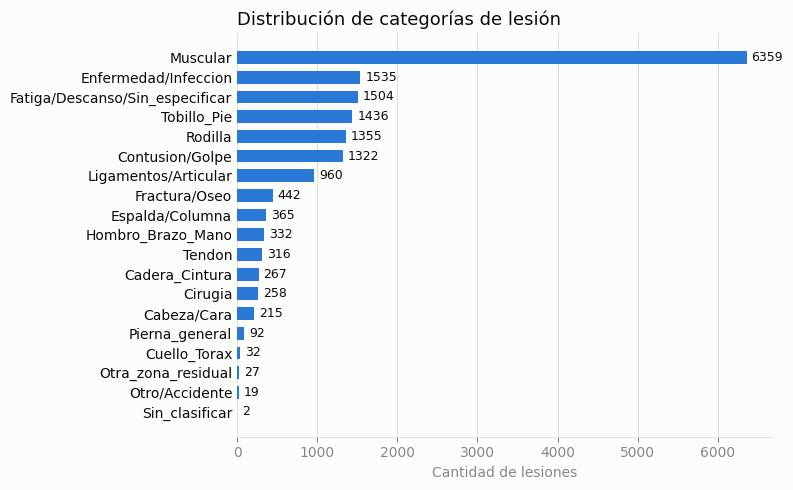

In [8]:
# Bar chart of injury category distribution
import matplotlib.pyplot as plt

SERIES_COLOR = "#2a78d6"
INK_PRIMARY = "#0b0b0b"
INK_MUTED = "#898781"
GRID_COLOR = "#e1e0d9"

plot_data = category_table.sort_values("count", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

bars = ax.barh(plot_data["injury_category"], plot_data["count"], color=SERIES_COLOR, height=0.65)

for bar, count in zip(bars, plot_data["count"]):
    ax.text(bar.get_width() + max(plot_data["count"]) * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{count}", va="center", ha="left", fontsize=9, color=INK_PRIMARY)

ax.set_xlabel("Cantidad de lesiones", color=INK_MUTED, fontsize=10)
ax.set_title("Distribución de categorías de lesión", color=INK_PRIMARY, fontsize=13, loc="left")
ax.tick_params(axis="y", colors=INK_PRIMARY, length=0)
ax.tick_params(axis="x", colors=INK_MUTED)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color(GRID_COLOR)
ax.xaxis.grid(True, color=GRID_COLOR, linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Sección 3 — Filtrado del panel grande (streaming)

`player_day_panel.csv` (~515 MB) es demasiado pesado para cargarlo completo en memoria. Lo procesamos en **streaming con `pandas.read_csv(chunksize=...)`**: leemos el archivo en bloques, y en cada bloque nos quedamos solo con las filas cuyo `tm_player_id` corresponde a algún jugador que aparece en `tm_injuries_clean.csv` (es decir, jugadores que tuvieron al menos una lesión registrada).

El resultado filtrado se guarda en `data/processed/player_day_panel_filtered.csv`.

In [9]:
# IDs of players with at least one recorded injury
injured_ids = set(injuries_df["tm_player_id"].unique())
print(f"Jugadores con lesion registrada: {len(injured_ids)}")

Jugadores con lesion registrada: 2047


In [10]:
# Stream-filter the panel in chunks, writing incrementally to avoid holding it all in memory
PANEL_PATH = RAW_DIR / "player_day_panel.csv"
FILTERED_PATH = PROCESSED_DIR / "player_day_panel_filtered.csv"
CHUNK_SIZE = 200_000

total_rows = 0
kept_rows = 0
first_chunk = True

start = time.time()
for chunk in tqdm(pd.read_csv(PANEL_PATH, chunksize=CHUNK_SIZE), desc="filtering panel"):
    total_rows += len(chunk)
    filtered_chunk = chunk[chunk["tm_player_id"].isin(injured_ids)]
    kept_rows += len(filtered_chunk)

    filtered_chunk.to_csv(
        FILTERED_PATH,
        mode="w" if first_chunk else "a",
        header=first_chunk,
        index=False,
    )
    first_chunk = False

elapsed = time.time() - start
pct_kept = kept_rows / total_rows * 100
filtered_size_mb = FILTERED_PATH.stat().st_size / (1024 ** 2)

print(f"Filas leidas: {total_rows:,}")
print(f"Filas retenidas: {kept_rows:,} ({pct_kept:.1f}%)")
print(f"Tiempo: {elapsed:.1f}s")
print(f"Tamano del archivo filtrado: {filtered_size_mb:.2f} MB")

filtering panel: 0it [00:00, ?it/s]

Filas leidas: 12,925,536
Filas retenidas: 12,758,518 (98.7%)
Tiempo: 69.5s
Tamano del archivo filtrado: 508.92 MB


## Sección 4 — Join final

Unimos las tres fuentes para armar el dataset final a nivel jugador-día:

1. **`player_mapping_tm.csv`** traduce `tm_player_id` (Transfermarkt) a `fbref_player_id` (FBref). Antes de mergear, chequeamos si tiene una fila por jugador o una fila por (jugador, temporada) — en cuyo caso un mismo `tm_player_id` aparecería repetido con distinto `fbref_player_id` según la temporada, y mergear tal cual multiplicaría filas del panel (fan-out). Si detectamos duplicados, deduplicamos a una fila por `tm_player_id` (nos quedamos con la temporada más reciente) antes de mergear.
2. Mergeamos el panel filtrado con el mapping (deduplicado si corresponde) por `tm_player_id`.
3. Mergeamos el resultado con las lesiones categorizadas usando la clave compuesta `["tm_player_id", "injury_spell_id"]`: el panel trae `injury_spell_id` vacío en los días sanos y poblado en los días que forman parte de un episodio de lesión, así que este join solo completa `injury_category` en esas filas y deja `NaN` en los días sanos.

Guardamos el resultado como `data/processed/dataset_final.csv`.

In [11]:
# Load remaining sources
mapping_df = pd.read_csv(RAW_DIR / "player_mapping_tm.csv")
panel_filtered_df = pd.read_csv(PROCESSED_DIR / "player_day_panel_filtered.csv")

print(f"mapping_df: {mapping_df.shape}")
print(f"panel_filtered_df: {panel_filtered_df.shape}")

mapping_df: (6999, 5)
panel_filtered_df: (12758518, 10)


In [12]:
# Check mapping cardinality: one row per player, or one row per (player, season)?
n_rows = len(mapping_df)
n_unique_ids = mapping_df["tm_player_id"].nunique()
print(f"Filas en mapping: {n_rows}")
print(f"tm_player_id unicos: {n_unique_ids}")

if n_rows > n_unique_ids:
    print(f"Duplicados detectados ({n_rows - n_unique_ids} filas extra) -> deduplicando (keep='last')")
    mapping_dedup = mapping_df.drop_duplicates(subset="tm_player_id", keep="last")
else:
    print("Sin duplicados -> se usa el mapping tal cual")
    mapping_dedup = mapping_df

print(f"mapping_dedup: {mapping_dedup.shape}")
assert mapping_dedup["tm_player_id"].is_unique, "mapping_dedup still has duplicate tm_player_id"

Filas en mapping: 6999
tm_player_id unicos: 2283
Duplicados detectados (4716 filas extra) -> deduplicando (keep='last')
mapping_dedup: (2283, 5)


In [13]:
# NOTE: the panel already carries its own fbref_player_id per row, correctly
# varying by season (verified against mapping_dedup for a sample player).
# Merging mapping_dedup's fbref_player_id in would overwrite that per-season
# value with a single (latest-season) value, corrupting earlier rows.
# So we only bring in descriptive columns from the mapping (player, team),
# and keep the panel's own fbref_player_id as the source of truth.
mapping_meta = mapping_dedup[["tm_player_id", "player", "team"]]

panel_mapped_df = panel_filtered_df.merge(mapping_meta, on="tm_player_id", how="left")

n_unmatched = panel_mapped_df["player"].isna().sum()
print(f"panel_mapped_df: {panel_mapped_df.shape}")
print(f"Filas sin match en mapping: {n_unmatched}")

assert len(panel_mapped_df) == len(panel_filtered_df), "Fan-out detectado en el merge con mapping"

panel_mapped_df: (12758518, 12)
Filas sin match en mapping: 0


In [14]:
# Merge with categorized injuries via composite key (tm_player_id, injury_spell_id).
# The panel's injury_spell_id is NaN on healthy days and populated on injury-episode
# days, so this join fills injury_category only where the panel actually flags an episode.
injuries_join = injuries_df[["tm_player_id", "injury_spell_id", "injury_category"]].copy()

dataset_final = panel_mapped_df.merge(
    injuries_join,
    on=["tm_player_id", "injury_spell_id"],
    how="left",
)

print(f"dataset_final: {dataset_final.shape}")
print(f"Filas con injury_category asignada: {dataset_final['injury_category'].notna().sum()}")

assert len(dataset_final) == len(panel_filtered_df), "Fan-out detectado en el join con lesiones"

dataset_final.to_csv(PROCESSED_DIR / "dataset_final.csv", index=False)
print("Guardado en data/processed/dataset_final.csv")

dataset_final: (12758518, 13)
Filas con injury_category asignada: 39393


Guardado en data/processed/dataset_final.csv


## Sección 5 — Verificación

Chequeos finales de integridad sobre `dataset_final.csv`:

1. Cantidad de filas y columnas.
2. Cantidad de jugadores únicos.
3. Chequeo de huérfanos: jugadores con lesión registrada (`tm_injuries_clean.csv`) que no encontraron su fila correspondiente en el join final (es decir, ninguna fila del dataset final con ese `tm_player_id` + `injury_spell_id` quedó con `injury_category` asignada).
4. Chequeo anti fan-out: el dataset final debe tener la misma cantidad de filas que el panel filtrado (Sección 3), confirmando que el merge con el mapping no duplicó filas.

In [15]:
# Basic shape and player counts
n_rows, n_cols = dataset_final.shape
n_unique_fbref = dataset_final["fbref_player_id"].nunique()
n_unique_tm = dataset_final["tm_player_id"].nunique()

print(f"Filas: {n_rows:,}")
print(f"Columnas: {n_cols}")
print(f"Jugadores unicos (fbref_player_id): {n_unique_fbref}")
print(f"Jugadores unicos (tm_player_id): {n_unique_tm}")

Filas: 12,758,518
Columnas: 13
Jugadores unicos (fbref_player_id): 6671
Jugadores unicos (tm_player_id): 2047


In [16]:
# Orphan check: injury episodes (tm_player_id, injury_spell_id) that never
# matched a row in the final dataset with a non-null injury_category
injured_spells = injuries_df[["tm_player_id", "injury_spell_id"]].drop_duplicates()
matched_spells = dataset_final.loc[
    dataset_final["injury_category"].notna(), ["tm_player_id", "injury_spell_id"]
].drop_duplicates()

orphans = injured_spells.merge(
    matched_spells, on=["tm_player_id", "injury_spell_id"], how="left", indicator=True
).query("_merge == 'left_only'")

print(f"Episodios de lesion totales: {len(injured_spells)}")
print(f"Episodios matcheados en dataset_final: {len(matched_spells)}")
print(f"Episodios huerfanos (sin match): {len(orphans)}")

if len(orphans) > 0:
    print("\nEjemplos de huerfanos:")
    print(orphans[["tm_player_id", "injury_spell_id"]].head(10))

Episodios de lesion totales: 16838
Episodios matcheados en dataset_final: 6611
Episodios huerfanos (sin match): 10227

Ejemplos de huerfanos:
    tm_player_id  injury_spell_id
0         434207                0
1         434207                1
7         434207                7
8          92571                8
24        591949               24
25        591949               25
27        591949               27
28        591949               28
29        591949               29
30        591949               30


El chequeo anterior muestra una cantidad alta de episodios huérfanos (~61%). Antes de aceptar el dataset final, investigamos la causa: comparamos la fecha de inicio (`start_date`) de cada episodio huérfano contra el rango de fechas que ese mismo jugador cubre en `player_day_panel.csv` (`date` mínima y máxima por `tm_player_id`).

Si el huérfano cae **fuera** de ese rango, es una lesión ocurrida en un período no cubierto por el panel (por ejemplo, antes de fichar por un club incluido en el dataset, después de irse, o en un préstamo/etapa fuera de cobertura) — una limitación real de los datos fuente, no un error del join. Si cayera **dentro** del rango sin explicación, sería señal de un problema real en la construcción del panel o del join.

In [17]:
# Explain orphans: does each orphan's start_date fall outside that player's
# own date coverage in the panel? (using start_date only, since end_date has nulls)
player_date_range = panel_filtered_df.groupby("tm_player_id")["date"].agg(["min", "max"])
player_date_range.columns = ["panel_min_date", "panel_max_date"]

orphans_with_dates = orphans.merge(
    injuries_df[["tm_player_id", "injury_spell_id", "start_date"]],
    on=["tm_player_id", "injury_spell_id"],
    how="left",
)
orphans_explained = orphans_with_dates.merge(player_date_range, on="tm_player_id", how="left")
outside_coverage = (
    (orphans_explained["start_date"] < orphans_explained["panel_min_date"])
    | (orphans_explained["start_date"] > orphans_explained["panel_max_date"])
)

n_outside = outside_coverage.sum()
n_unexplained = (~outside_coverage).sum()

print(f"Huerfanos totales: {len(orphans_explained)}")
print(f"Huerfanos con start_date fuera del rango de cobertura del jugador: {n_outside} ({n_outside / len(orphans_explained) * 100:.1f}%)")
print(f"Huerfanos sin explicar (start_date dentro del rango): {n_unexplained}")

if n_unexplained > 0:
    print("\nRevisar estos casos manualmente:")
    print(orphans_explained.loc[~outside_coverage, ["tm_player_id", "injury_spell_id", "start_date", "panel_min_date", "panel_max_date"]])
else:
    print("\nConclusion: el 100% de los huerfanos corresponde a lesiones fuera del periodo")
    print("que el jugador aparece en el panel (limitacion de cobertura de los datos fuente, no un bug del join).")

Huerfanos totales: 10227
Huerfanos con start_date fuera del rango de cobertura del jugador: 10227 (100.0%)
Huerfanos sin explicar (start_date dentro del rango): 0

Conclusion: el 100% de los huerfanos corresponde a lesiones fuera del periodo
que el jugador aparece en el panel (limitacion de cobertura de los datos fuente, no un bug del join).


In [18]:
# Anti fan-out check: final dataset must have the same row count as the filtered panel
assert len(dataset_final) == len(panel_filtered_df), "Fan-out detectado en el join"
print(f"OK: dataset_final tiene las mismas {len(dataset_final):,} filas que panel_filtered_df")

OK: dataset_final tiene las mismas 12,758,518 filas que panel_filtered_df
